# Caso 6 - Pruebas de Hipótesis. ¿Cómo saber si A y B son independientes?
En este nuevo caso, aprenderemos un poco sobre las pruebas utilizadas en estadística para determinar si dos variables (una de ellas categórica) están relacionadas entre sí. Esta es una pregunta muy importante porque es la que responde a preguntas como ¿la vacuna que desarrollamos funciona? ¿nuestra nueva página web mejora la experiencia del usuario? ¿hay una relación entre el nivel educativo de la gente y sus preferencias políticas?

El aprendizaje se realizará en el contexto de dos bases de datos, la primera relacionando la calidad del vino con muchas de sus características, y la segunda relacionando el color de los ojos con el color de cabello en una muestra de muchas personas.

## Resultado previsto de aprendizaje
Al finalizar este caso, el estudiante será capaz de:
- Verificar y validar los supuestos de normalidad y homogeneidad de varianzas para aplicar pruebas t.
- Aplicar correctamente la prueba t de Student para establecer diferencias entre grupos según variables continuas.
- Implementar la prueba chi-cuadrado de independencia en variables categóricas.
- Usar métodos de bootstraping como métodos no-paramétricos de comparación entre dos muestras.

## Contexto del Problema
- Usted hace parte de un equipo de análisis sensorial en una bodega de vinos. Desea identificar si existen diferencias estadísticamente significativas en las características fisicoquímicas (como el contenido de alcohol, acidez, pH, entre otras) entre vinos de distinta calidad. ¿Qué variables permiten discriminar mejor entre calidades? ¿Qué tan robusta es la diferencia entre vinos de calidad media y alta?

- También colabora en un estudio demográfico para entender si existen patrones comunes entre características físicas. ¿Está relacionado el color de ojos con el color de cabello en la población analizada? ¿Hay dependencia estadística entre ambas variables?

Primero importamos las librerías que usaremos

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, ttest_rel, ttest_1samp

# Análisis de calidad de vinos

En la primera parte de este caso usaremos una base de datos 1599 vinos. Cada vino contiene 11 características numéricas que lo caracterizan como su acidez fija, acidez volátil, ácido cítrico, etc. Al final, además, hay una clasificación numérica de la calidad del vino, esta se da en una escala entera entre 3 y 8 (mayor significa mejor calidad). Más información sobre este dataset se puede encontrar aquí:

https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009/data 

Procedemos entonces a importar nuestros datos

In [2]:
wine_q = pd.read_csv('data/winequality-red.csv')
wine_q

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


Veamos con qué tipo de datos estamos trabajando

In [3]:
wine_q.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

En este caso todas nuestras variables serán numéricas, y se puede establecer que contamos con 11 características (columnas) que caracterizan las propiedades del vino, y una columna adicional entera que caracteriza la calidad del vino.

Veamos un resumen rápido de información valiosa que se puede obtener inicialmente.

In [4]:
wine_q.describe().T.style.background_gradient(axis=0)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.000000,8.319637,1.741096,4.600000,7.100000,7.900000,9.200000,15.900000
volatile acidity,1599.000000,0.527821,0.179060,0.120000,0.390000,0.520000,0.640000,1.580000
citric acid,1599.000000,0.270976,0.194801,0.000000,0.090000,0.260000,0.420000,1.000000
residual sugar,1599.000000,2.538806,1.409928,0.900000,1.900000,2.200000,2.600000,15.500000
chlorides,1599.000000,0.087467,0.047065,0.012000,0.070000,0.079000,0.090000,0.611000
free sulfur dioxide,1599.000000,15.874922,10.460157,1.000000,7.000000,14.000000,21.000000,72.000000
total sulfur dioxide,1599.000000,46.467792,32.895324,6.000000,22.000000,38.000000,62.000000,289.000000
density,1599.000000,0.996747,0.001887,0.990070,0.995600,0.996750,0.997835,1.003690
pH,1599.000000,3.311113,0.154386,2.740000,3.210000,3.310000,3.400000,4.010000
sulphates,1599.000000,0.658149,0.169507,0.330000,0.550000,0.620000,0.730000,2.000000


Podemos calcular la variabilidad de los datos como la razón entre la desviación estándar y el promedio

In [5]:
data = wine_q.describe().T
data['variability'] = data['std']/data['mean']
data.sort_values(by='variability', ascending = False)

,count,mean,std,min,25%,50%,75%,max,variability
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000,0.718888
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000,0.707917
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000,0.658911
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000,0.555351
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100,0.538095
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000,0.339244
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000,0.257551
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000,0.209276
quality,1599.0,5.636023,0.807569,3.00000,5.0000,6.00000,6.000000,8.00000,0.143287
alcohol,1599.0,10.422983,1.065668,8.40000,9.5000,10.20000,11.100000,14.90000,0.102242


Como vemos, el ácido cítrico y el dióxido de azufre son las cantidades que mayor variabilidad tienen en la base de datos (cantidades que más varián de un vino a otro). Por otro lado, el pH y la densidad son las cantidades que menos cambios tienen a lo largo de la base de datos. Ahora podemos hacer una serie de gráficas que nos permita observar cómo cambian estas cantidades con la calidad del vino.

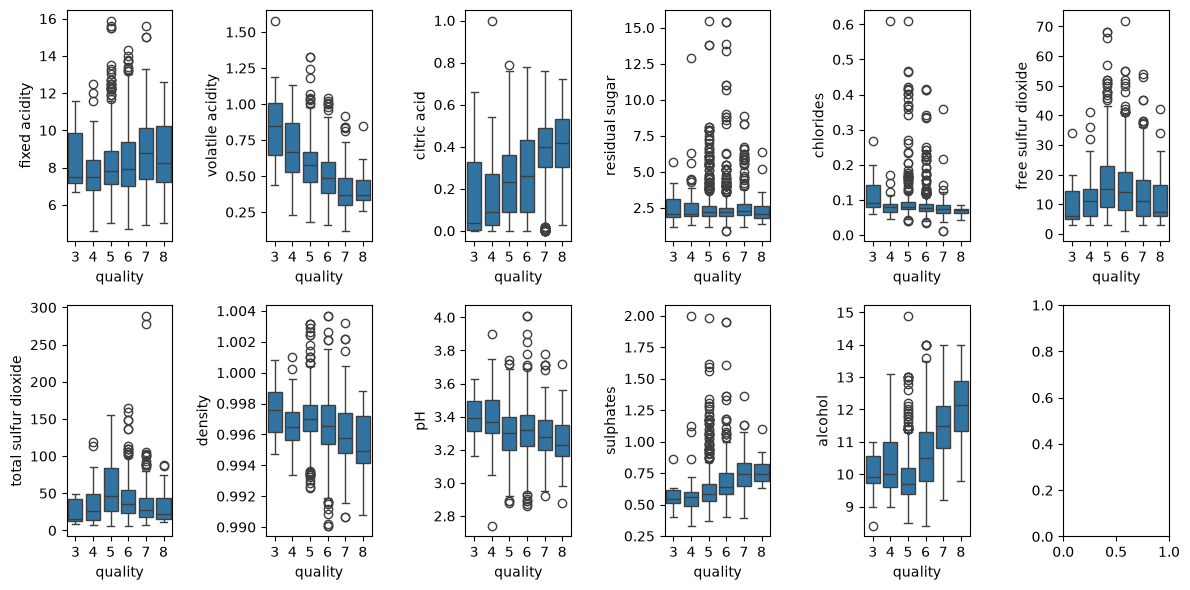

In [6]:
# creando la figura
fig, ax = plt.subplots(2,6,figsize=(12, 6))

# iteramos sobre las columnas de la tabla
for i, col_name in enumerate(wine_q.columns[:-1]):
    row = i // 6 # filas
    col = i % 6 # columnas
    # graficamos el boxplot
    sns.boxplot(data = wine_q, x='quality', y = col_name , ax=ax[row][col])
# arreglamos el espacio entre los subplots
plt.tight_layout()

Veamos ahora cómo se distribuye el vino de acuerdo con su calidad

<Axes: xlabel='quality', ylabel='count'>

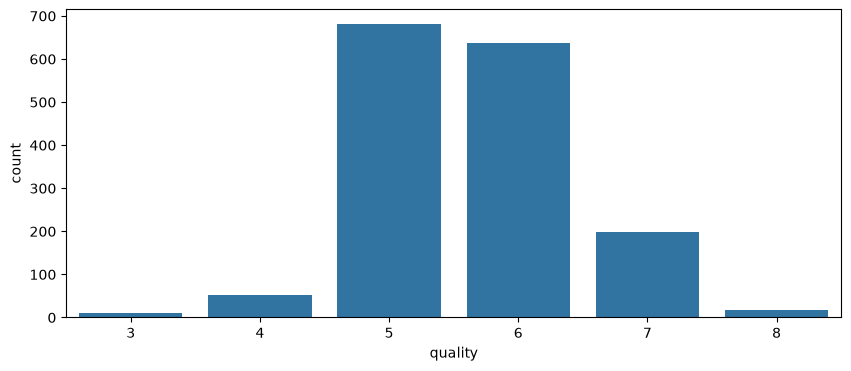

In [7]:
# creando una figura mostrando el conteo de valores por calidad
fig, ax = plt.subplots(figsize=(10, 4))
# graficamos el conteo de valores por calidad
sns.countplot(data = wine_q, x='quality', ax=ax)

Como se observa, la mayoría de los vinos se encuentra en los rangos 5 y 6 de calidad.

## Dos niveles de calidad

Vamos entonces a hacer una definición que nos permita separar los vinos de muy buena calidad de los demás, la definición será la siguiente:

- Vino de muy buena calidad: si calidad >= 8

- Vino de muy mala calidad: si calidad <= 3

- Vino estándar: si calidad entre 4 y 7

Agreguemos esta definición a nuestra base de datos


In [8]:
# creamos la columna calidad
wine_q['calidad'] = 'estándar'
# creamos una máscara para los vinos de alta calidad
mask = wine_q['quality'] >= 8
# asignamos la calidad alta a los vinos de alta calidad
wine_q.loc[mask, 'calidad'] = 'alta' 
# creamos una máscara para los vinos de baja calidad
mask = wine_q['quality'] <= 3
# asignamos la calidad baja a los vinos de baja calidad
wine_q.loc[mask, 'calidad'] = 'baja'

wine_q

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,calidad
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,estándar
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,estándar
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,estándar
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,estándar
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,estándar
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,estándar
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,estándar
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,estándar
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,estándar


## ¿Qué variables son las que más cambian entre los vinos estándar y de alta calidad?

La pregunta que queremos resolver ahora es: ¿hay una diferencia clara entre la distribución de algunas propiedades para los vinos estándar y de muy alta calidad? Para responder a esta pregunta usaremos una prueba llamada t-test.

### Ejemplo: la densidad

Analicemos ahora el caso de la densidad, y analicemos si hay un cambio significativo de este valor entre los vinos con calidad baja y los de calidad alta. Arranquemos con la visualización de la distribución de la densidad para los grupos de calidad.



<Axes: xlabel='calidad', ylabel='density'>

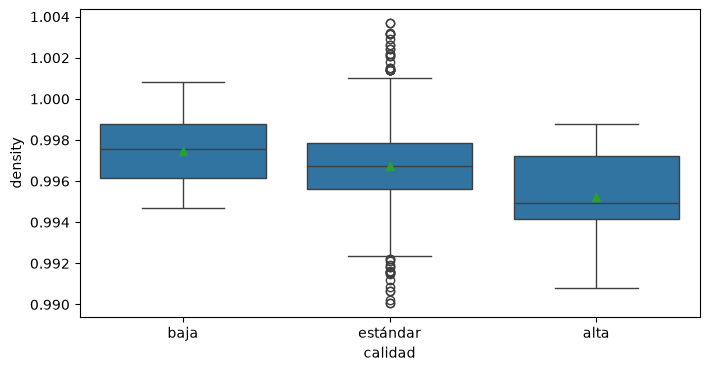

In [9]:
# graficando la distribución de densidad del vino para diferentes calidades
fig, ax = plt.subplots(figsize=(8, 4))
# fijando un orden para las calidades
order = ['baja', 'estándar', 'alta']
# usamos un boxplot de seaborn para crear la visualización
sns.boxplot(data = wine_q, x='calidad', y = 'density', order=order, showmeans=True, ax=ax)

La pregunta es entonces, ¿es esta diferencia estadísticamente significativa? Apliquemos un t-test para determinar cuál es la probabilidad de hacer esta observación, asumiendo que las dos distribuciones para la calidad baja y calidad alta **son muy similares**.

Formalmente, para aplicar un t-test, se deben cumplir una serie de requerimientos:

- Las variables a comparar deben ser cuantitativas y continuas 
- Las muestras a comparar deben ser independientes entre sí
- La variable debe seguir una distribución aproximadamente normal
- Homogeneidad de varianzas, las varianzas de los grupos deben ser iguales para la versión clásica del t-test

Las dos primeras condiciones se aseguran en el análisis exploratorio de datos, es decir, para este punto ya están validadas. Para las siguiente pruebas es necesario hacer pruebas.

### Prueba de normalidad el test de Shapiro-Wilk
En este test se prueba la hipótesis nula de que la muestra a estudiar tiene una distribución normal. Entonces el *p-valor* se puede interpretar como la probabilidad de observar la muestra estudiada, asumiendo que ha sido tomada de una distribución normal. Si esta probabilidad se torna demasiado baja, se puede concluir entonces que la distribución no es normal y no se puede usar t-test.

In [10]:
# Normalidad
from scipy.stats import shapiro

mask_alta = wine_q['calidad'] == 'alta'  
stat, p = shapiro(wine_q.loc[mask_alta,'density']) 
print(f"Calidad alta: p = {p:.3f}")  # p < 0.05 confirma que no podemos asumir normalidad
mask_baja = wine_q['calidad'] == 'baja'
stat, p = shapiro(wine_q.loc[mask_baja,'density'])  
print(f"Calidad baja: p = {p:.3f}")  # p < 0.05 confirma que no podemos asumir normalidad

Calidad alta: p = 0.550
Calidad baja: p = 0.838


Como se ve, no hay suficiente evidencia estadística como para rechazar la normalidad. Esto no es una confirmación de normalidad, sólo nos dice que no hay suficiente evidencia estadística como para asumir lo contrario.

### Prueba de homogeneidad
La homogeneidad de varianzas se puede probar con el test de Levene. En este test la hipótesis nula es que las dos muestras tienen la misma varianza, el *p-valor* correspondiente entonces nos dice cuál es la probabilidad de hacer la observación que estamos estudiando asumiendo que las varianzas son iguales. En caso de que este valor sea muy pequeño, descartamos la hipótesis nula y concluimos que las varianzas son diferentes.

In [11]:
# Homogeneidad
from scipy.stats import levene

stat, p = levene(wine_q.loc[mask_baja,'density'], wine_q.loc[mask_alta,'density'])
print(f"p = {p:.3f}")  # p < 0.05 → asumimos varianzas diferentes

p = 0.542


### Realizando el t-test
Una vez validadas estos supuestos es hora de poner en marcha nuestra prueba t-test. En el caso en el que no exista homogeneidad entre las varianzas de las dos muestras se puede usar el Welch-test, el cual en python tiene la misma implementación que t-test con la adición de especificar `equal_var=False`. Si por el contrario, los datos no cuentan con normalidad o ninguna de los suspuestos, se pueden usar tests no paramétricos.

In [12]:
# t-test
t_stat, p_value = ttest_ind(wine_q.loc[mask_baja,'density'], wine_q.loc[mask_alta,'density'])
print(f"T = {t_stat:.3f}, p = {p_value:.3f}")

T = 2.532, p = 0.018


Para el caso de este análisis, se tiene que si $p$-valor < 0.05, sí existe una diferencia significativa entre las dos muestras. Este es justo nuestro caso, un *p-valor* de 0.018 quiere decir que la probabilidad de observar nuestros datos, asumiendo que las medias de los dos grupos son iguales, es de apenas el 1.8%. Es decir las dos distribuciones son estadisticamente diferentes , eso quiere decir que si se quiere hacer un vino de buena calidad , la densidad es una variable de alto impacto

### Ejemplo: el alcohol

Ahora hagamos este mismo análisis con otra variable, veamos el alcohol. Primero gráficamente, luego evaluamos supuestos para finalmente usar la prueba t-test

In [13]:
# graficamos el alcohol por calidad usando un boxplot en plotly
import plotly.express as px
# fijamos un orden para las calidades
order = ['baja', 'estándar', 'alta']

# graficamos el boxplot
fig = px.box(wine_q, x='calidad', y='alcohol', points='all', title='Densidad por calidad', category_orders={'calidad': order})
fig.update_traces(marker=dict(size=5))
fig.update_layout(title_x=0.5)
fig.show()

In [14]:
# Normalidad
stat, p = shapiro(wine_q.loc[mask_alta,'alcohol']) 
print(f"Calidad alta: p = {p:.3f}")  # p < 0.05 confirma que no podemos asumir normalidad
stat, p = shapiro(wine_q.loc[mask_baja,'alcohol'])  
print(f"Calidad baja: p = {p:.3f}")  # p < 0.05 confirma que no podemos asumir normalidad

Calidad alta: p = 0.668
Calidad baja: p = 0.579


In [15]:
# Homogeneidad
stat, p = levene(wine_q.loc[mask_baja,'alcohol'], wine_q.loc[mask_alta,'alcohol'])
print(f"p = {p:.3f}")  # p < 0.05 → asumimos varianzas diferentes

p = 0.087


La prueba de homogeneidad es superior al límite, para estar seguros, podemos hacer el t-test asumiendo varianzas iguales y sin asumir varianzas iguales

In [16]:
# t-test de varianzas iguales
t_stat, p_value = ttest_ind(wine_q.loc[mask_baja,'alcohol'], wine_q.loc[mask_alta,'alcohol'], equal_var=True)
print(f"varianzas iguales, T = {t_stat:.3f}, p = {p_value:.3f}")
# t-test de varianzas diferentes
t_stat, p_value = ttest_ind(wine_q.loc[mask_baja,'alcohol'], wine_q.loc[mask_alta,'alcohol'], equal_var=False)
print(f"varianzas diferentes, T = {t_stat:.3f}, p = {p_value:.3f}")


varianzas iguales, T = -4.929, p = 0.000
varianzas diferentes, T = -5.521, p = 0.000


En ambos casos el *p-valor* es extremadamente pequeño, lo que nos sugiere que definitivamente el nivel de alcohol en los dos grupos: calidad baja y calidad alta, es diferente. Por lo cual es una variable de acto impacto para la calidad del vino.

Si quisiéramos analizar el impacto de una variable sobre todas todos nuestro valores de calidad de vino, es posible; en ese caso el problema evoluciona a un análisis de ANOVA, sin embargo ese tema lo desarrollaremos en nuestro siguiente caso de estudio.

___
#### Ejercicio 1
Grafique un boxplot comparando la variable `density` para los vinos de calidad 5 y 7
___

In [21]:
wine_filtered = wine_q[wine_q['quality'].isin([5, 7])]
wine_filtered

# graficamos el alcohol por calidad usando un boxplot en plotly
import plotly.express as px

# graficamos el boxplot
fig = px.box(wine_filtered, x='quality', y='density', points='all', title='Densidad por calidad', category_orders={'quality': [5,7]})
fig.update_traces(marker=dict(size=5))
fig.update_layout(title_x=0.5)
fig.show()


___
#### Ejercicio 2
Evalue los supuestos de la prueba t-test de la variable `density` para los vinos de calidad 5 y 7. Existe normalidad y homogeneidad entre los datos?
___

In [41]:
# Normalidad
mask_5 = wine_filtered['quality'] == 5  
stat, p = shapiro(wine_filtered.loc[mask_5,'density']) 
print(f"Calidad 5: p = {p:.3f}")  # p < 0.05 confirma que no podemos asumir normalidad
mask_7 = wine_filtered['quality'] == 7  
stat, p = shapiro(wine_filtered.loc[mask_7,'density'])  
print(f"Calidad 7: p = {p:.3f}")  # p < 0.05 confirma que no podemos asumir normalidad

Calidad 5: p = 0.000
Calidad 7: p = 0.076


In [42]:
# Homogeneidad
stat, p = levene(wine_filtered.loc[mask_5,'density'], wine_filtered.loc[mask_7,'density'])
print(f"p = {p:.3f}")  # p < 0.05 → asumimos varianzas diferentes


p = 0.000


La calidad **7 sí es normal** (Shapiro p = 0.076, no se rechaza la normalidad), pero la calidad **5 no lo es** (p = 0.000), y las varianzas **no son homogéneas** (Levene p = 0.000). Como al menos un grupo viola la normalidad y además las varianzas difieren, **no se cumplen los supuestos del t-test clásico**. Lo estrictamente correcto sería una prueba no paramétrica (Mann-Whitney U); aun así, en el Ejercicio 3 aplicamos el t-test de Welch como pide el enunciado, teniendo en cuenta las varianzas distintas.

___
#### Ejercicio 3
Realice una prueba t-test para determinar si existen diferencias significativas en la variable `density` para los vinos de calidad 5 y 7. 
___

In [43]:
# t-test de varianzas diferentes
t_stat, p_value = ttest_ind(wine_filtered.loc[mask_5,'density'], wine_filtered.loc[mask_7,'density'], equal_var=False)
print(f"varianzas diferentes, T = {t_stat:.3f}, p = {p_value:.3f}")

varianzas diferentes, T = 6.027, p = 0.000


In [ ]:
# Verificación no paramétrica (los supuestos no se cumplían): Mann-Whitney U
from scipy.stats import mannwhitneyu
u_stat, p_mw = mannwhitneyu(wine_filtered.loc[mask_5,'density'], wine_filtered.loc[mask_7,'density'])
print(f"Mann-Whitney U: p = {p_mw:.2e}  -> {'diferencia significativa' if p_mw < 0.05 else 'no significativa'}")

**Respuesta Ejercicio 3.** Con el t-test de Welch (varianzas diferentes, como indicó Levene) se obtiene **T = 6.027, p ≈ 5.6×10⁻⁹**. Como **p < 0.05, sí existe una diferencia estadísticamente significativa** en la densidad entre los vinos de calidad 5 (media 0.99710) y calidad 7 (media 0.99610).

La prueba no paramétrica Mann-Whitney U (la apropiada dado que los supuestos no se cumplían) **confirma el resultado** (p ≈ 4.3×10⁻¹²), así que la conclusión es robusta. La diferencia absoluta es pequeña (~0.001), pero el tamaño de efecto es moderado (Cohen d ≈ 0.58): la diferencia es real, no trivial.

___
#### Ejercicio 4
Realice una prueba t-test para determinar si existen diferencias significativas en la variable `alcohol` para los vinos de calidad 7 y 8. Tenga en cuenta evaluar los supuestos antes de correr la prueba.
___

In [44]:
wine_filtered_7_y_8 = wine_q[wine_q['quality'].isin([7, 8])]
wine_filtered_7_y_8

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,calidad
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.99460,3.39,0.47,10.00,7,estándar
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.99680,3.36,0.57,9.50,7,estándar
16,8.5,0.28,0.56,1.8,0.092,35.0,103.0,0.99690,3.30,0.75,10.50,7,estándar
37,8.1,0.38,0.28,2.1,0.066,13.0,30.0,0.99680,3.23,0.73,9.70,7,estándar
62,7.5,0.52,0.16,1.9,0.085,12.0,35.0,0.99680,3.38,0.62,9.50,7,estándar
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1541,7.4,0.25,0.29,2.2,0.054,19.0,49.0,0.99666,3.40,0.76,10.90,7,estándar
1544,8.4,0.37,0.43,2.3,0.063,12.0,19.0,0.99550,3.17,0.81,11.20,7,estándar
1549,7.4,0.36,0.30,1.8,0.074,17.0,24.0,0.99419,3.24,0.70,11.40,8,alta
1555,7.0,0.56,0.17,1.7,0.065,15.0,24.0,0.99514,3.44,0.68,10.55,7,estándar


In [47]:
# Normalidad
mask_7 = wine_filtered_7_y_8['quality'] == 7  
stat, p = shapiro(wine_filtered_7_y_8.loc[mask_7,'alcohol']) 
print(f"Calidad 7: p = {p:.3f}")  # p < 0.05 confirma que no podemos asumir normalidad
mask_8 = wine_filtered_7_y_8['quality'] == 8  
stat, p = shapiro(wine_filtered_7_y_8.loc[mask_8,'alcohol'])  
print(f"Calidad 8: p = {p:.3f}")  # p < 0.05 confirma que no podemos asumir normalidad

Calidad 7: p = 0.311
Calidad 8: p = 0.668


In [48]:
# Homogeneidad
stat, p = levene(wine_filtered_7_y_8.loc[mask_7,'alcohol'], wine_filtered_7_y_8.loc[mask_8,'alcohol'])
print(f"p = {p:.3f}")  # p < 0.05 → asumimos varianzas diferentes



p = 0.099


In [49]:
# t-test
t_stat, p_value = ttest_ind(wine_filtered_7_y_8.loc[mask_7,'alcohol'], wine_filtered_7_y_8.loc[mask_8,'alcohol'])
print(f"T = {t_stat:.3f}, p = {p_value:.3f}")

T = -2.592, p = 0.010


**Respuesta Ejercicio 4.**

**Supuestos (sí se cumplen).** Ambos grupos son normales — Shapiro calidad 7 (p=0.311) y calidad 8 (p=0.668), en los dos casos p ≥ 0.05 — y las varianzas son homogéneas — Levene (p=0.099 ≥ 0.05). A diferencia de los ejercicios anteriores, **aquí sí se satisfacen los supuestos**, por lo que el t-test de Student con varianzas iguales (`equal_var=True`, el valor por defecto) es la prueba adecuada.

**Resultado.** T = -2.592, p = 0.010. Como **p < 0.05, sí existe una diferencia estadísticamente significativa** en el alcohol entre los vinos de calidad 7 y 8. La calidad **8 tiene más alcohol (media 12.09 %)** que la calidad 7 (media 11.47 %), una diferencia de ~0.63 puntos; el signo negativo de T se debe a que el primer grupo (calidad 7) tiene la media menor.

**Robustez y matices.** El tamaño de efecto es medio-grande (Cohen d ≈ -0.64) y las pruebas alternativas coinciden (Mann-Whitney U p=0.024; Welch p=0.047). No obstante, **la calidad 8 solo tiene 18 vinos** (muestra pequeña), lo que resta potencia estadística; el resultado debe tomarse con esa cautela, aunque las tres pruebas apuntan a lo mismo: los vinos de mayor calidad tienden a tener más alcohol.

### Métodos Bootstrapping - No Paramétricos
En años recientes, los métodos de bootstrapping han tomado fuerza sobre los métodos estadísticos debido a la creciente capacidad de cómputo y a que permiten evitar el cumplimiento de los supuestos detrás de muchas pruebas estadísticas.

Como vimos al final del análisis anterior, los vinos de calidad baja y alta, fueron definidos en extremos marginales de calidad 3 y 8. Alguien podría decir: *Por qué no hacer categorías más amplias para tener más datos, 3-4 categoría baja, 5-6 categoría estándar, 7-8 categoría alta*. Claramente esta es una posibilidad razonable, pero como veremos, hace que nuestros supuestos no funcionen.

In [50]:
# redefiniendo los niveles de calidad
wine_q['calidad'] = 'estándar'
# creando una máscara para los vinos de alta calidad
mask_alta = wine_q['quality'] >= 7
# asignando la calidad alta a los vinos de alta calidad
wine_q.loc[mask_alta, 'calidad'] = 'alta'
# creando una máscara para los vinos de baja calidad
mask_baja = wine_q['quality'] <= 4
# asignando la calidad baja a los vinos de baja calidad
wine_q.loc[mask_baja, 'calidad'] = 'baja'


Veamos la distribución de calidades en nuestra muestra

In [51]:
wine_q['calidad'].value_counts()

calidad
estándar    1319
alta         217
baja          63
Name: count, dtype: int64

Realicemos de nuevo la gráfica y observemos cómo ahora tenemos más datos en las categorías de baja y alta calidad

In [52]:
# graficamos el alcohol por calidad usando un boxplot en plotly
import plotly.express as px
# fijamos un orden para las calidades
order = ['baja', 'estándar', 'alta']

# graficamos el boxplot
fig = px.box(wine_q, x='calidad', y='alcohol', points='all', title='Densidad por calidad', category_orders={'calidad': order})
fig.update_traces(marker=dict(size=5))
fig.update_layout(title_x=0.5)
fig.show()

Evaluemos por ejemplo ahora, los supuestos de normalidad de las distribuciones

In [53]:
# Normalidad
stat, p = shapiro(wine_q.loc[mask_alta,'alcohol']) 
print(f"Calidad alta: p = {p:.3f}")  # p < 0.05 confirma que no podemos asumir normalidad
stat, p = shapiro(wine_q.loc[mask_baja,'alcohol'])  
print(f"Calidad baja: p = {p:.3f}")  # p < 0.05 confirma que no podemos asumir normalidad

Calidad alta: p = 0.232
Calidad baja: p = 0.032


Como se observa, aunque los datos de alta calidad no son concluyentes, los de baja calidad sí permiten desechar la hipótesis nula de que la distribución es normal. ¿No se puede entonces verificar si las distribuciones son diferentes? La respuesta es SI.

#### Usando bootstrapping
Vamos a usar un método de muestreo aleatorio para estimar cuál sería la distribución esperada del valor absoluto de la diferencia de medias de dos grupos de datos, el proceso a seguir es el siguiente:
- Como la hipótesis nula es que los dos grupos de datos vienen de la misma población, los vamos a juntar.
- Posteriormente vamos a hacer múltiples particiones aleatorias del grupo de datos total, siempre con longitudes `np.sum(mask_baja)` y `np.sum(mask_alta)`
- Para cada partición calculamos el valor absoluto de la diferencia de medias. Esto nos va a generar una distribución.
- Miramos cuál es la probabilidad de observar valores tan o más extremos que los observados en esta distribución, ese es el *p-valor*

Veamos:

In [54]:
# generamos una única base de datos con los vinos de calidad alta y baja
wine_bootstrap = pd.concat([wine_q.loc[mask_alta], wine_q.loc[mask_baja]])
wine_bootstrap['calidad'].value_counts()

calidad
alta    217
baja     63
Name: count, dtype: int64

Una vez tenemos una base de datos sólo con los datos de alta y de baja calidad, procedemos con el bootstrapping. Vamos a hacer el proceso 10000 veces, el código para realizarlo es el siguiente:

Text(0, 0.5, 'Frecuencia')

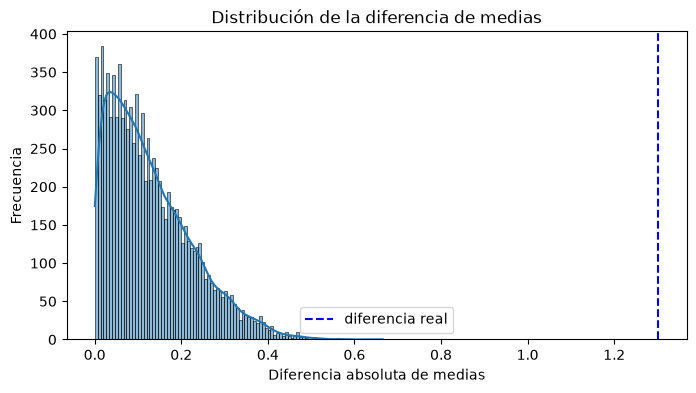

In [55]:
# generamos un listado vacío para guardar los resultados
abs_mean_bootstrap = []
# definimos cuántos bootstraps queremos hacer
n_bootstrap = 10000
# iteramos sobre el número de bootstraps
for i in range(n_bootstrap):
    # desordenamos la base de datos
    sample = wine_bootstrap.sample(frac=1, replace=False, random_state=i)
    # calculamos la media de los primeros np.sum(mask_baja) datos
    mean_baja = sample.iloc[:np.sum(mask_baja)]['alcohol'].mean()
    mean_alta = sample.iloc[np.sum(mask_baja):]['alcohol'].mean()
    # guardamos la diferencia de medias
    abs_mean_bootstrap.append(np.abs(mean_baja - mean_alta))

# graficamos el histograma de las diferencias de medias
fig, ax = plt.subplots(figsize=(8, 4))
# graficamos el histograma de las diferencias de medias
sns.histplot(data = abs_mean_bootstrap, bins=100, kde=True, ax=ax)
# graficamos la línea de la media
abs_mean_real = np.abs(np.mean(wine_q.loc[mask_alta,'alcohol'])-np.mean(wine_q.loc[mask_baja,'alcohol']))
ax.axvline(abs_mean_real, color='blue', linestyle='--', label='diferencia real')
# añadimos la leyenda
ax.legend()
# añadimos los nombres de los ejes
ax.set_title('Distribución de la diferencia de medias') 
ax.set_xlabel('Diferencia absoluta de medias')
ax.set_ylabel('Frecuencia')



Como vemos, hemos generado una distribución de diferencias absolutas de medias. Nuestra diferencia absoluta real se encuentra muy lejos de esa distribución. Ahora procedemos a calcular el *p-valor* como la proporción de diferencias absolutas en el bootstrapping que es mayor o igual a la diferencia observada:

In [56]:
# calculamos el p-valor
p_value = np.sum(np.array(abs_mean_bootstrap) >= abs_mean_real) / len(abs_mean_bootstrap)
print(f"p-value = {p_value:.3f}")

p-value = 0.000


Así las cosas,claramente sí existe una diferencia estadísticamente significativa en la cantidad de alcohol observada entre los vinos de alta y de baja calidad. Pero, ¿podemos aplicar el método para encontrar otras variables que también son significativamente diferentes entre estos dos grupos?

In [57]:
# creamos un dataframe vacío para guardar los resultados
results = pd.DataFrame(columns=['parametro', 'p_value'])
# definimos cuántos bootstraps queremos hacer
n_bootstrap = 10000
# iteramos sobre las columnas de la tabla
for col_name in wine_q.columns[:-2]:
    # creamos un listado vacío para guardar los resultados
    abs_mean_bootstrap = []
    # iteramos sobre el número de bootstraps
    for i in range(n_bootstrap):
        # desordenamos la base de datos
        sample = wine_q.sample(frac=1, replace=False, random_state=i)
        # calculamos la media de los primeros np.sum(mask_baja) datos
        mean_baja = sample.iloc[:np.sum(mask_baja)][col_name].mean()
        mean_alta = sample.iloc[np.sum(mask_baja):][col_name].mean()
        # guardamos la diferencia de medias
        abs_mean_bootstrap.append(np.abs(mean_baja - mean_alta))
    # calculamos la diferencia real
    abs_mean_real = np.abs(np.mean(wine_q.loc[mask_alta,col_name])-np.mean(wine_q.loc[mask_baja,col_name]))
    # calculamos el p-valor
    p_value = np.sum(np.array(abs_mean_bootstrap) >= abs_mean_real) / len(abs_mean_bootstrap)
    # guardamos los resultados
    results = pd.concat([results, pd.DataFrame({'parametro': col_name, 'p_value': p_value}, index=[0])], ignore_index=True)
# ordenamos los resultados por p-valor
results = results.sort_values(by='p_value')

results
    

,parametro,p_value
0,fixed acidity,0.0
1,volatile acidity,0.0
2,citric acid,0.0
8,pH,0.0
9,sulphates,0.0
10,alcohol,0.0
4,chlorides,0.0039
7,density,0.0064
5,free sulfur dioxide,0.151
3,residual sugar,0.8984


Como observamos, esta técnica nos permite establecer que para la mayoría de las variables hay una diferencia estadísicamente significativa entre los vinos de baja calidad (3-4) y los vinos de alta calidad (7-8). Solo en el caso del Dióxido de Azufre y el azúcar residual no se puede concluir que haya diferencia entre los dos grupos.

## Prueba chi-cuadrado para determinar la independencia entre variables categóricas

La prueba chi-cuadrado (χ²) es una prueba estadística no paramétrica que se utiliza para analizar si existe una relación significativa entre dos variables categóricas. Es ampliamente empleada en estudios sociales, de mercado, médicos y en general siempre que se desea evaluar si los patrones observados en una tabla de frecuencias se deben al azar o reflejan una asociación real entre las variables.

Se usa principialmente para dos propósitos:
- Prueba de independencia: Evalúa si dos variables categóricas están relacionadas o si son independientes.
- Prueba de bondad de ajuste: Compara una distribución observada con una esperada (teórica) para ver si los datos siguen un patrón específico.

Con la prueba de Chi-squared es necesario que se cumplan ciertas condiciones:
- Datos categóricos: Las variables deben ser categóricas, si existen numéricas deben ser agrupadas en categorías primero.
- Los datos deben estar en forma de frecuencias (conteos), no en porcentajes o proporciones.
- Cada observación debe pertenecer a una sola categoría de cada variable. Es decir, no deben existir variables repetidas.

Ahora analizaremos una nueva base de datos, la cual hace referencia a la frecuencia con la que hay personas con cierto tipo de color de cabello y ojos. La idea en este caso es determinar si la distribución de color de ojos cambia con respecto al color de cabello.

In [58]:
color = pd.read_csv("data/HairEyeColor.csv")
color.head(5)

,Unnamed: 0,Hair,Eye,Sex,Freq
0,1,Black,Brown,Male,32
1,2,Brown,Brown,Male,53
2,3,Red,Brown,Male,10
3,4,Blond,Brown,Male,3
4,5,Black,Blue,Male,11


Podemos eliminar la primer columna ya que no representa imformación importante para nuestro caso

In [59]:
color = color.drop(columns='Unnamed: 0')
color.head(5)

,Hair,Eye,Sex,Freq
0,Black,Brown,Male,32
1,Brown,Brown,Male,53
2,Red,Brown,Male,10
3,Blond,Brown,Male,3
4,Black,Blue,Male,11


Para el caso propio, no analizaremos el efecto del sexo en nuestros datos por lo que podemos agrupar

In [60]:
grouped_data = color.groupby(['Hair', 'Eye'])['Freq'].sum().reset_index()
grouped_data

,Hair,Eye,Freq
0,Black,Blue,20
1,Black,Brown,68
2,Black,Green,5
3,Black,Hazel,15
4,Blond,Blue,94
5,Blond,Brown,7
6,Blond,Green,16
7,Blond,Hazel,10
8,Brown,Blue,84
9,Brown,Brown,119


Podemos visualizar estos datos de forma gráfica, de manera que sea más evidente la distribución de colores de ojos para diferentes colores de cabello

In [61]:
# graficamos la distribución de color de ojos por color de pelo, usando plotly
# creamos una nueva columna con la frecuencia relativa
grouped_data['Rel_Freq'] = grouped_data['Freq'] / grouped_data.groupby('Hair')['Freq'].transform('sum')
# creamos la figura en plotly
fig = px.bar(grouped_data, x='Hair', y='Rel_Freq', color='Eye', barmode='stack', title='Distribución relativa de colores de ojos por color de pelo')
# añadimos la leyenda
fig.update_layout(title_x=0.5)
# añadimos los nombres de los ejes
fig.update_xaxes(title_text='Color de pelo')
fig.update_yaxes(title_text='Frecuencia relativa')
# añadimos la leyenda
fig.update_traces(marker=dict(line=dict(width=0.5, color='black')))
# graficamos la figura
fig.show()

Alternativamente podemos graficar la distribución de color de pelo para cada tipo de color de ojos

In [62]:
# graficamos la distribución de color de pelo por color de ojos, usando plotly
# creamos una nueva columna con la frecuencia relativa
grouped_data['Rel_Freq_eyes'] = grouped_data['Freq'] / grouped_data.groupby('Eye')['Freq'].transform('sum')
# creamos la figura en plotly
fig = px.bar(grouped_data, x='Eye', y='Rel_Freq_eyes', color='Hair', barmode='stack', title='Distribución relativa de colores de pelo por color de ojos')
# añadimos la leyenda
fig.update_layout(title_x=0.5)
# añadimos los nombres de los ejes
fig.update_xaxes(title_text='Color de ojos')
fig.update_yaxes(title_text='Frecuencia relativa')
# añadimos la leyenda
fig.update_traces(marker=dict(line=dict(width=0.5, color='black')))
# graficamos la figura
fig.show()

El objetivo de la prueba Chi-cuadrado (chi-squared, $\Chi^2$) es determinar si estas distribuciones son significativamente diferentes para las diferentes categorías. Para aplicarla, es necesario transformar el formato de nuestros datos para que quede en forma matricial. Esto se logra con la función `pivot` de pandas.

In [63]:
pivot_table = grouped_data.pivot(index='Hair', columns='Eye', values='Freq').fillna(0)
print(pivot_table)

Eye    Blue  Brown  Green  Hazel
Hair                            
Black    20     68      5     15
Blond    94      7     16     10
Brown    84    119     29     54
Red      17     26     14     14


En este punto podemos correr nuestra prueba, la implementación se ve de la siguiente manera:

In [64]:
from scipy.stats import chi2_contingency
chi2_stat, p_value, dof, expected = chi2_contingency(pivot_table)

print(f"\nChi-Square Statistic: {chi2_stat:.4f}")
print(f"P-Value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")
print("\nExpected Frequencies:")
print(pd.DataFrame(expected, index=pivot_table.index, columns=pivot_table.columns))

# Interpretation
if p_value < 0.05:
    print("\nSe rechaza la hipótesis nula: El color de cabello y de los ojos es dependiente entre ellos")
else:
    print("\nNo se rechaza la hipótesis nula: El color de cabello y de los ojos no es dependiente")


Chi-Square Statistic: 138.2898
P-Value: 0.0000
Degrees of Freedom: 9

Expected Frequencies:
Eye          Blue       Brown      Green      Hazel
Hair                                               
Black   39.222973   40.135135  11.675676  16.966216
Blond   46.123311   47.195946  13.729730  19.951014
Brown  103.868243  106.283784  30.918919  44.929054
Red     25.785473   26.385135   7.675676  11.153716

Se rechaza la hipótesis nula: El color de cabello y de los ojos es dependiente entre ellos


Las frecuencias esperadas corresponden a las frecuencias que se observarían si la distribución del color de pelo fuera la misma, independiente del color de ojos, y viceversa. La prueba chi-cuadrado determina qué tan lejos está la distribución observada del comportamiento ideal. La métrica que se usa es la siguiente:
$$\Chi^2 = \sum{\frac{(O-E)^2}{E}}$$
En donde la suma se hace sobre cada celda de la tabla de contingencia, $O$ corresponde al valor observado y $E$ es el valor esperado si las dos variables fueran independientes. Valores más grandes de $\Chi^2$ indican mayores desviaciones de los valores esperados.

El *p-valor* en este caso, corresponde a la probabilidad de observar el valor de $\Chi^2$ suponiendo que las dos variables son independientes.

En este caso, a partir del análisis se llega a la conclusión de que sí existe una dependencia entre el color de cabello y los ojos de las personas. Finalmente, podemos ir un poco más allá y calcular qué tan fuerte es esa dependencia. Esta cuantificación se hace con el V de Cramer:
$$V=\sqrt{\frac{\Chi^2}{n\cdot\min{(r-1,c-1)}}}$$
Como se observa, la V de Cramer normaliza el parámetro $\Chi^2$ al número total de observaciones, $n$, y al número de grados de libertad del sistema, relacionado con el número de filas $r$, y el número de columnas $c$. 

In [65]:
n = pivot_table.to_numpy().sum()  # Total sample size
min_dim = min(pivot_table.shape) - 1
cramers_v = np.sqrt(chi2_stat / (n * min_dim)) # Cramer's V: Medida del tamaño de la dependencia
print(f"Cramér's V (Tamaño del efecto): {cramers_v:.3f}")

if cramers_v <= 0.1:
    print("Efecto pequeño")
elif cramers_v <= 0.3:
    print("Efecto medio")
else:
    print("Efecto grande")

Cramér's V (Tamaño del efecto): 0.279
Efecto medio


___
#### Ejercicio 5
Realice una prueba chi-squared para determinar si existe dependencia entre el color de ojos y el sexo
___

In [67]:
grouped_data_eye_sex = color.groupby(['Eye', 'Sex'])['Freq'].sum().reset_index()
grouped_data_eye_sex

,Eye,Sex,Freq
0,Blue,Female,114
1,Blue,Male,101
2,Brown,Female,122
3,Brown,Male,98
4,Green,Female,31
5,Green,Male,33
6,Hazel,Female,46
7,Hazel,Male,47


In [76]:
# graficamos la distribución de color de ojos por el sexo, usando plotly
# creamos una nueva columna con la frecuencia relativa
grouped_data_eye_sex['Rel_Freq_Sex'] = grouped_data_eye_sex['Freq'] / grouped_data_eye_sex.groupby('Sex')['Freq'].transform('sum')
# creamos la figura en plotly
fig = px.bar(grouped_data_eye_sex, x='Sex', y='Rel_Freq_Sex', color='Eye', barmode='stack', title='Distribución relativa de colores de ojos por sexo')
# añadimos la leyenda
fig.update_layout(title_x=0.5)
# añadimos los nombres de los ejes
fig.update_xaxes(title_text='Sexo')
fig.update_yaxes(title_text='Frecuencia relativa')
# añadimos la leyenda
fig.update_traces(marker=dict(line=dict(width=0.5, color='black')))
# graficamos la figura
fig.show()

In [79]:
# graficamos la distribución del sexo por el color de ojos  , usando plotly
# creamos una nueva columna con la frecuencia relativa
grouped_data_eye_sex['Rel_Freq_Eye'] = grouped_data_eye_sex['Freq'] / grouped_data_eye_sex.groupby('Eye')['Freq'].transform('sum')
# creamos la figura en plotly
fig = px.bar(grouped_data_eye_sex, x='Eye', y='Rel_Freq_Eye', color='Sex', barmode='stack', title='Distribución relativa del sexo por color de ojos')
# añadimos la leyenda
fig.update_layout(title_x=0.5)
# añadimos los nombres de los ejes
fig.update_xaxes(title_text='Color de ojos')
fig.update_yaxes(title_text='Frecuencia relativa')
# añadimos la leyenda
fig.update_traces(marker=dict(line=dict(width=0.5, color='black')))
# graficamos la figura
fig.show()

In [83]:


pivot_table_eye_sex = grouped_data_eye_sex.pivot(index='Eye', columns='Sex', values='Freq').fillna(0)
print(  pivot_table_eye_sex)

Sex    Female  Male
Eye                
Blue      114   101
Brown     122    98
Green      31    33
Hazel      46    47


In [85]:
from scipy.stats import chi2_contingency
chi2_stat, p_value, dof, expected = chi2_contingency(pivot_table_eye_sex)

print(f"\nChi-Square Statistic: {chi2_stat:.4f}")
print(f"P-Value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")
print("\nExpected Frequencies:")
print(pd.DataFrame(expected, index=pivot_table_eye_sex.index, columns=pivot_table_eye_sex.columns))

# Interpretation
if p_value < 0.05:
    print("\nSe rechaza la hipótesis nula: El color de ojos y el sexo es dependiente entre ellos")
else:
    print("\nNo se rechaza la hipótesis nula: El color de ojos y el sexo no es dependiente")


Chi-Square Statistic: 1.5298
P-Value: 0.6754
Degrees of Freedom: 3

Expected Frequencies:
Sex        Female        Male
Eye                          
Blue   113.673986  101.326014
Brown  116.317568  103.682432
Green   33.837838   30.162162
Hazel   49.170608   43.829392

No se rechaza la hipótesis nula: El color de ojos y el sexo no es dependiente


___
#### Ejercicio 6
Realice una prueba chi-squared para determinar si existe dependencia entre el color de cabello y el sexo.
___

In [87]:
grouped_data_hair_sex = color.groupby(['Hair', 'Sex'])['Freq'].sum().reset_index()
grouped_data_hair_sex

,Hair,Sex,Freq
0,Black,Female,52
1,Black,Male,56
2,Blond,Female,81
3,Blond,Male,46
4,Brown,Female,143
5,Brown,Male,143
6,Red,Female,37
7,Red,Male,34


In [88]:
# graficamos la distribución de color de cabello por el sexo, usando plotly
# creamos una nueva columna con la frecuencia relativa
grouped_data_hair_sex['Rel_Freq_Sex'] = grouped_data_hair_sex['Freq'] / grouped_data_hair_sex.groupby('Sex')['Freq'].transform('sum')
# creamos la figura en plotly
fig = px.bar(grouped_data_hair_sex, x='Sex', y='Rel_Freq_Sex', color='Hair', barmode='stack', title='Distribución relativa de colores de cabello por sexo')
# añadimos la leyenda
fig.update_layout(title_x=0.5)
# añadimos los nombres de los ejes
fig.update_xaxes(title_text='Sexo')
fig.update_yaxes(title_text='Frecuencia relativa')
# añadimos la leyenda
fig.update_traces(marker=dict(line=dict(width=0.5, color='black')))
# graficamos la figura
fig.show()

In [89]:
# graficamos la distribución del sexo por el color de cabello  , usando plotly
# creamos una nueva columna con la frecuencia relativa
grouped_data_hair_sex['Rel_Freq_Hair'] = grouped_data_hair_sex['Freq'] / grouped_data_hair_sex.groupby('Hair')['Freq'].transform('sum')
# creamos la figura en plotly
fig = px.bar(grouped_data_hair_sex, x='Hair', y='Rel_Freq_Hair', color='Sex', barmode='stack', title='Distribución relativa del sexo por color de cabello')
# añadimos la leyenda
fig.update_layout(title_x=0.5)
# añadimos los nombres de los ejes
fig.update_xaxes(title_text='Color de cabello')
fig.update_yaxes(title_text='Frecuencia relativa')
# añadimos la leyenda
fig.update_traces(marker=dict(line=dict(width=0.5, color='black')))
# graficamos la figura
fig.show()

In [90]:


pivot_table_hair_sex = grouped_data_hair_sex.pivot(index='Hair', columns='Sex', values='Freq').fillna(0)
print(  pivot_table_hair_sex)

Sex    Female  Male
Hair               
Black      52    56
Blond      81    46
Brown     143   143
Red        37    34


In [91]:
from scipy.stats import chi2_contingency
chi2_stat, p_value, dof, expected = chi2_contingency(pivot_table_hair_sex)

print(f"\nChi-Square Statistic: {chi2_stat:.4f}")
print(f"P-Value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")
print("\nExpected Frequencies:")
print(pd.DataFrame(expected, index=pivot_table_hair_sex.index, columns=pivot_table_hair_sex.columns))

# Interpretation
if p_value < 0.05:
    print("\nSe rechaza la hipótesis nula: El color de cabello y el sexo es dependiente entre ellos")
else:
    print("\nNo se rechaza la hipótesis nula: El color de cabello y el sexo no es dependiente")


Chi-Square Statistic: 7.9942
P-Value: 0.0461
Degrees of Freedom: 3

Expected Frequencies:
Sex        Female        Male
Hair                         
Black   57.101351   50.898649
Blond   67.146959   59.853041
Brown  151.212838  134.787162
Red     37.538851   33.461149

Se rechaza la hipótesis nula: El color de cabello y el sexo es dependiente entre ellos


___
#### Ejercicio 7
En caso de que en el ejercicio 5 o 6 haya obtenido dependencia entre los datos, determine qué tan fuerte es la dependencia.
___

In [92]:
n = pivot_table_hair_sex.to_numpy().sum()  # Total sample size
min_dim = min(pivot_table_hair_sex.shape) - 1
cramers_v = np.sqrt(chi2_stat / (n * min_dim)) # Cramer's V: Medida del tamaño de la dependencia
print(f"Cramér's V (Tamaño del efecto): {cramers_v:.3f}")

if cramers_v <= 0.1:
    print("Efecto pequeño")
elif cramers_v <= 0.3:
    print("Efecto medio")
else:
    print("Efecto grande")

Cramér's V (Tamaño del efecto): 0.116
Efecto medio


# Conclusión
En este análisis se aplicaron pruebas de hipótesis para explorar diferencias y asociaciones significativas en dos conjuntos de datos distintos. Con la prueba t para muestras independientes, se evaluaron las características fisicoquímicas del vino según su calidad, validando previamente los supuestos de normalidad y homogeneidad de varianzas, lo que permitió identificar variables con diferencias estadísticamente significativas entre categorías. Adicionalmente, mediante la prueba chi-cuadrado de independencia se examinó la relación entre el color de ojos y el color de cabello, cuantificando la fuerza de esta asociación a través de Cramér's V. Estos enfoques permitieron establecer conclusiones sólidas sobre la dependencia entre variables categóricas y las diferencias entre grupos, reforzando la importancia del análisis estadístico riguroso en la toma de decisiones basada en datos.

### Origen de los datos

- Base de Datos de Calidad de Vino
https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009/data

- Base de Datos de Color de Ojos y Color de Cabello. https://www.kaggle.com/datasets/jasleensondhi/hair-eye-color/data
